### Intro to Python Programming
- Prof Joanna Bieri
- Office: Duke 209

### Day 20 - Putting the pieces together

Today we are going to work on writing some code that puts some important ideas together. This notebook will allow you to practice the following important ideas.

- Data Types
- Loops
- User Input
- Functions
- Pandas
- Plotting
- Geopandas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


import geopandas as gpd
import cartopy
import cartopy.crs as ccrs

### We will start by loading some data into a Pandas Data Frame

In [2]:
website='https://joannabieri.com/python/'

file_name = website + "FruitPrices2020.csv"
DFfruit = pd.read_csv(file_name)
file_name = website + 'VegetablePrices2020.csv'
DFveg = pd.read_csv(file_name)
DF = pd.concat([DFfruit,DFveg],ignore_index=True)

### Look at the Pandas Data below

In [3]:
DF.head(5)

,Item,Form,RetailPrice,RetailPriceUnit,Yield,CupEquivalentSize,CupEquivalentUnit,CupEquivalentPrice
0,Apples,Fresh,1.5193,per pound,0.90,0.2425,pounds,0.4094
1,"Apples, applesauce",Canned,1.0660,per pound,1.00,0.5401,pounds,0.5758
2,"Apples, ready-to-drink",Juice,0.7804,per pint,1.00,8.0000,fluid ounces,0.3902
3,"Apples, frozen concentrate",Juice,0.5853,per pint,1.00,8.0000,fluid ounces,0.2926
4,Apricots,Fresh,2.9665,per pound,0.93,0.3638,pounds,1.1603


#### What are the Column Names?

In [4]:
# Your code here
DF.columns

Index(['Item', 'Form', 'RetailPrice', 'RetailPriceUnit', 'Yield',
       'CupEquivalentSize', 'CupEquivalentUnit', 'CupEquivalentPrice'],
      dtype='object')

#### What are the Data Types in each Column?

You can either use the built in Pandas functions or figure it out by looking at the DataFrame.

- Check your answer using a command like:
     
      type(DF['Item'].iloc[0])
      
- What does the .iloc[0] do?

In [5]:
# Your code here
DF.dtypes

Item                   object
Form                   object
RetailPrice           float64
RetailPriceUnit        object
Yield                 float64
CupEquivalentSize     float64
CupEquivalentUnit      object
CupEquivalentPrice    float64
dtype: object

#### How many rows are in the data?

In [6]:
# Your code here
# 155 rows 
DF.shape

(155, 8)

#### Write a FOR loop that loops through each string in the Item column and prints out all the items.

In [7]:
# Your code here
for item in DF['Item']:
    print(item)

Apples
Apples, applesauce
Apples, ready-to-drink
Apples, frozen concentrate
Apricots
Apricots, packed in juice
Apricots, packed in syrup or water
Apricots
Bananas
Berries, mixed
Blackberries
Blackberries
Blueberries
Blueberries
Cantaloupe
Cherries
Cherries, packed in syrup or water
Clementines
Cranberries
Dates
Figs
Fruit cocktail, packed in juice
Fruit cocktail, packed in syrup or water
Grapefruit
Grapefruit, ready-to-drink
Grapes
Grapes (raisins)
Grapes, ready-to-drink
Grapes, frozen concentrate
Honeydew
Kiwi
Mangoes
Mangoes
Nectarines
Oranges
Oranges, ready-to-drink
Oranges, frozen concentrate
Papaya
Papaya
Peaches
Peaches, packed in juice
Peaches, packed in syrup or water
Peaches
Pears
Pears, packed in juice
Pears, packed in syrup or water
Pineapple
Pineapple, packed in juice
Pineapple, packed in syrup or water
Pineapple
Pineapple, ready-to-drink
Pineapple, frozen concentrate
Plum
Plum (prunes)
Plum (prune), ready-to-drink
Pomegranate
Pomegranate, ready-to-drink
Raspberries
Raspber

#### Write a FOR loop that loops through each string in the Item column and checks if the word "Apple" is in the string. IF "Apple" is in the string print the string.

In [9]:
# Your code here
for item in DF['Item']:
    if "Apple" in item:
        print(item)

Apples
Apples, applesauce
Apples, ready-to-drink
Apples, frozen concentrate


#### How many unique entries are there in the column "Form"?

In [11]:
# Your code here
DF['Form'].nunique()

5

#### Write a FOR loop that loops through the unique entries in the column 'Form' and prints them out.

In [13]:
# Your code here
for form in DF['Form'].dropna().unique():
    print(form)

Fresh
Canned
Juice
Dried
Frozen


#### Write a function that given a DataFrame will return a random row from that DataFrame.

In [14]:
# Your code here
def random_row(DF):
    return DF.sample(n=1)

#### Write a function that takes as an input from a user. Ask the user for a dollar amount and then choose a random row from the data frame and prints out what the item and form are and how many pounds of that item a person could buy.

NOTE - you should be able to call the function you wrote in the step above to get the random row.



In [18]:
# Your code here
def random_purchase(DF):
    dollars = float(input())
    row = random_row(DF).iloc[0]
    print(row['Item'], row['Form'], round(dollars / row['RetailPrice'], 2))
random_purchase(DF)

 50


Pinto beans Canned 57.2


#### Write a function that asks the user to name a fruit or vegetable and then returns all the rows in the DataFrame that contain that fruit or vegetable in their Item column (string).

NOTE - Remeber you aready wrote above to look for string matches in the items.

NOTE - My strategy for this involved creating a mask on element at a time.

NOTE - You might want to use .title() on the users input to match the format in the data.

In [20]:
# Your code here
def find_item(DF):
    name = input().title()
    mask = DF['Item'].str.contains(name)
    return DF[mask]
find_item(DF)

 apple


,Item,Form,RetailPrice,RetailPriceUnit,Yield,CupEquivalentSize,CupEquivalentUnit,CupEquivalentPrice
0,Apples,Fresh,1.5193,per pound,0.9,0.2425,pounds,0.4094
1,"Apples, applesauce",Canned,1.0660,per pound,1.0,0.5401,pounds,0.5758
2,"Apples, ready-to-drink",Juice,0.7804,per pint,1.0,8.0000,fluid ounces,0.3902
3,"Apples, frozen concentrate",Juice,0.5853,per pint,1.0,8.0000,fluid ounces,0.2926


#### Using the function above, write a function that creates a bar plot of the DataFrame that is returned. You should plot the Item on the x-axis and the CupEquivalentPrice on the y-axis so the person can see the relative prices.

 apple


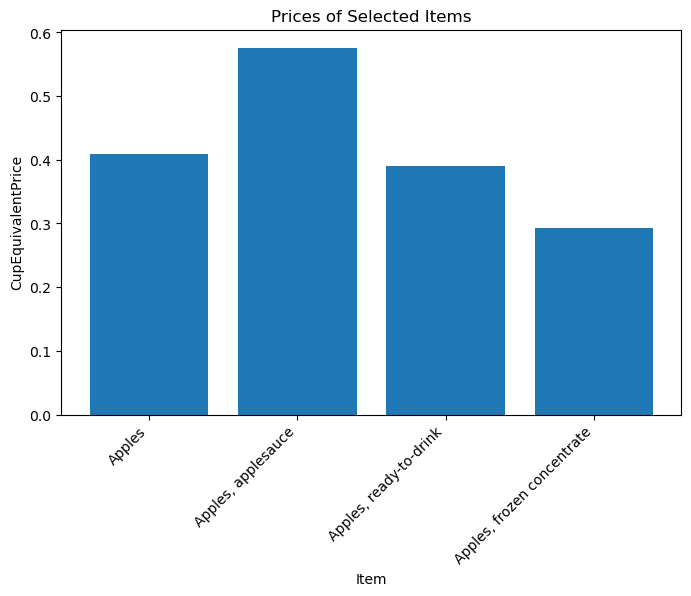

In [22]:
# Your code here
def plot_item_prices(DF):
    filtered_DF = find_item(DF)
    if filtered_DF.empty:
        print("No items found.")
        return
    
    plt.figure(figsize=(8,5))
    plt.bar(filtered_DF['Item'], filtered_DF['CupEquivalentPrice'])
    plt.xlabel('Item')
    plt.ylabel('CupEquivalentPrice')
    plt.title('Prices of Selected Items')
    plt.xticks(rotation=45, ha='right')
    plt.show()
plot_item_prices(DF)

#### CHALLENGE -  Write code that allows a user to look certain produce idems and saves their produce information list to a file that they can look at later.

- Ask the user to input a fruit or vegetable name.
- Look for that name in the strings in the DF['Item"] column
- Show the user all the rows that contain their fruit or vegetable. 
    - For example if my user gave me apple I would:
        - use .title() to make it Apple
        - search for any items that contain apple
        - create a mask so I get back just the rows about apples:
        
              0	Apples	Fresh	1.5193	per pound	0.9000	0.2425	pounds	0.4094
              1	Apples, applesauce	Canned	1.0660	per pound	1.0000	0.5401	pounds	0.5758
              2	Apples, to-drink	Juice	0.7804	per pint	1.0000	8.0000	fluid ounces  0.3902
              3	Apples, frozen conce	Juice	0.5853	per pint   1.0000	8.0000  fluid ounces 0.2926
               
- Let the user choose which row they want- eg 0,1,2,3 for apples
- Save that (.iloc[]) row to a list
- Let the user keep adding produce until they are done (WHILE loop)
- Once they are done, print the final data (DataFrame would look best) AND save the data as a .csv.

NOTE - you will want to allow for user errors like entering a word instead of an index. or doing silly things like users do.

In [80]:
# Your code here


In [30]:
import geodatasets as gd

ModuleNotFoundError: No module named 'geodatasets'

### Look at the GeoPandas Data below

In [23]:
borderDF = pd.read_csv('Border_Crossing_Entry_Data.csv')
geometry = gpd.points_from_xy(borderDF["Longitude"], borderDF["Latitude"])
gDF = gpd.GeoDataFrame(borderDF, geometry=geometry, crs=4326)

In [24]:
gDF.head()

,Port Name,State,Port Code,Border,Date,Measure,Value,Latitude,Longitude,Point,geometry
0,Roma,Texas,2310,US-Mexico Border,Dec 2023,Buses,46,26.404,-99.019,POINT (-99.018981 26.403928),POINT (-99.019 26.404)
1,Del Rio,Texas,2302,US-Mexico Border,Dec 2023,Trucks,6552,29.327,-100.928,POINT (-100.927612 29.326784),POINT (-100.928 29.327)
2,Roma,Texas,2310,US-Mexico Border,Nov 2023,Trucks,3753,26.404,-99.019,POINT (-99.018981 26.403928),POINT (-99.019 26.404)
3,Douglas,Arizona,2601,US-Mexico Border,Oct 2023,Buses,13,31.334,-109.560,POINT (-109.560344 31.334043),POINT (-109.56 31.334)
4,Beecher Falls,Vermont,206,US-Canada Border,Aug 2023,Trucks,422,45.013,-71.505,POINT (-71.505309 45.013411),POINT (-71.505 45.013)


#### This data contains border crossing information for each of the ports along the US border. 

Assume that 'Value' is the total number of people crossing using that 'Measure' for that 'Date'

#### Use the GeoPandas Plotting Tools to create a plot that is similar to the image below.

zsh:1: command not found: wget


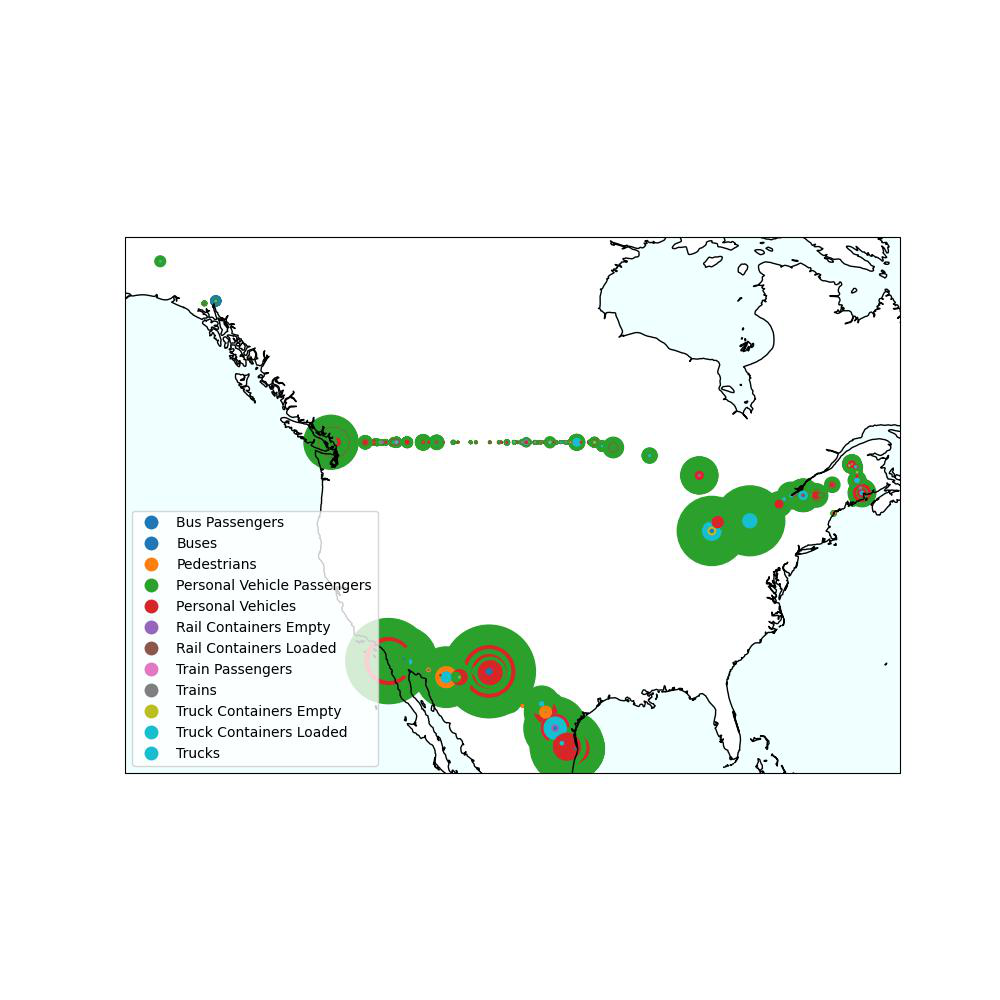

In [25]:
!wget https://joannabieri.com/python/BorderFig.jpg -O BorderFig.jpg
# importing PIL
from PIL import Image
# Read image
img = Image.open('BorderFig.jpg')
# Output Images
img

In [29]:
# Your code here
gdf = gd.datasets.load_dataset("naturalearth_lowres")

fig, ax = plt.subplots(figsize=(10,10))
gdf.plot(ax=ax, color="lightgreen", edgecolor="black")
gdf.boundary.plot(ax=ax, color="gray", linewidth=1)
ax.set_title("Styled Map like BorderFig.jpg", fontsize=16)
ax.set_axis_off()
plt.show()

NameError: name 'gd' is not defined

#### Challenge:

See if you can ask some more interesting questions of the data and write code to get the answers.
- Which border crossing was most busy
- Which border crossing was least busy
- What form of transport brings the bost people across the border
- Create a graph of the total number of border crossings per month in the data

In [ ]:
# Your code here
